# GSS Polarization Analysis - Single Model (Two Categories)

This notebook analyzes LLM polarization on GSS survey questions using a single model.

**Two categories of GSS questions:**
- **Public Issues**: Policy/political questions → uses `default` template: *"Generate a statement by {name} on {topic}."*
- **Private Life**: Personal/lifestyle questions → uses `opinion` template: *"What would {name} say about {topic}?"*

Results are saved to `../results/` folder.

## 1. Setup and Configuration

In [10]:
os.environ["TOKENIZERS_PARALLELISM"] = "false"  # Avoid warning with multiprocessing


In [ ]:
import sys; sys.path.insert(0, "..")
import os
os.environ["TOKENIZERS_PARALLELISM"] = "false"  # Avoid warning with multiprocessing

import pandas as pd
import numpy as np
import torch
import gc
import time
from datetime import datetime
from pathlib import Path

# Print import info
print("="*70)
print("IMPORTS AND CONFIGURATION")
print("="*70)

# Local imports with verbose logging
print("\n[Importing local modules...]")

from config import NOMINATE_CSV, SYSTEM_MSG_POLITICIAN
print(f"  ✓ config.py")
print(f"      NOMINATE_CSV = {NOMINATE_CSV}")
print(f"      SYSTEM_MSG_POLITICIAN = \"{SYSTEM_MSG_POLITICIAN[:60]}...\"")

from model_utils import load_model, extract_heads_batched, get_model_info
print(f"  ✓ model_utils.py: load_model, extract_heads_batched, get_model_info")

from metrics_utils import compute_all_head_metrics, summarize_metrics, add_derived_metrics
print(f"  ✓ metrics_utils.py: compute_all_head_metrics, summarize_metrics, add_derived_metrics")

from prompt_utils import load_politicians, generate_politician_prompts, POLITICIAN_TEMPLATES
print(f"  ✓ prompt_utils.py: load_politicians, generate_politician_prompts, POLITICIAN_TEMPLATES")
print(f"      Available templates: {list(POLITICIAN_TEMPLATES.keys())}")
for k, v in POLITICIAN_TEMPLATES.items():
    print(f"        - {k}: \"{v}\"")

import warnings
warnings.filterwarnings('ignore')

print("\n[All imports complete]")

In [2]:
# =============================================================================
# CONFIGURATION
# =============================================================================

# Model settings
MODEL_PATH = "/project/jevans/maxzhuyt/models/Meta-Llama-3.1-8B-Instruct"
MODEL_NAME = "Llama-3.1-8B"

# Output directory
OUTPUT_DIR = Path("llm_results")
OUTPUT_DIR.mkdir(exist_ok=True)

# Processing settings
BATCH_SIZE = 80
MAX_LENGTH = 128

# Category settings: each category has its own topic CSV, polarization CSV, and template
CATEGORIES = {
    "public_issues": {
        "topics_csv": "public_issues.csv",
        "polarization_csv": "public_issues_polarization.csv",
        "template_name": "default",  # "Generate a statement by {name} on {topic}."
    },
    "private_life": {
        "topics_csv": "private_life.csv",
        "polarization_csv": "private_life_polarization.csv",
        "template_name": "opinion",  # "What would {name} say about {topic}?"
    },
}

print("="*70)
print("CONFIGURATION SUMMARY")
print("="*70)
print(f"\n[Model]")
print(f"  Name: {MODEL_NAME}")
print(f"  Path: {MODEL_PATH}")
print(f"\n[Output]")
print(f"  Directory: {OUTPUT_DIR.absolute()}")
print(f"\n[Processing]")
print(f"  Batch size: {BATCH_SIZE}")
print(f"  Max sequence length: {MAX_LENGTH}")
print(f"\n[Categories]")
for cat_name, cat_config in CATEGORIES.items():
    template = POLITICIAN_TEMPLATES[cat_config['template_name']]
    print(f"  {cat_name}:")
    print(f"    - Topics CSV: {cat_config['topics_csv']}")
    print(f"    - Polarization CSV: {cat_config['polarization_csv']}")
    print(f"    - Template name: '{cat_config['template_name']}'")
    print(f"    - Template text: \"{template}\"")

CONFIGURATION SUMMARY

[Model]
  Name: Llama-3.1-8B
  Path: /project/jevans/maxzhuyt/models/Meta-Llama-3.1-8B-Instruct

[Output]
  Directory: /project/jevans/maxzhuyt/../results

[Processing]
  Batch size: 80
  Max sequence length: 128

[Categories]
  public_issues:
    - Topics CSV: public_issues.csv
    - Polarization CSV: public_issues_polarization.csv
    - Template name: 'default'
    - Template text: "Generate a statement by {name} on {topic}."
  private_life:
    - Topics CSV: private_life.csv
    - Polarization CSV: private_life_polarization.csv
    - Template name: 'opinion'
    - Template text: "What would {name} say about {topic}?"


## 2. Load Topics from CSV Files

In [3]:
def load_topics_from_csv(csv_path: str) -> dict:
    """
    Load topics from CSV file.
    
    Returns:
        Dict mapping Variable -> NaturalLanguageClause
    """
    df = pd.read_csv(csv_path)
    topics = dict(zip(df['Variable'], df['NaturalLanguageClause']))
    return topics, df


def load_polarization_data(csv_path: str) -> pd.DataFrame:
    """
    Load GSS survey polarization data.
    """
    df = pd.read_csv(csv_path)
    return df


# Load all topics and polarization data
print("="*70)
print("LOADING TOPICS AND POLARIZATION DATA")
print("="*70)

all_topics = {}
all_topics_df = {}
all_polarization = {}

for cat_name, cat_config in CATEGORIES.items():
    print(f"\n[{cat_name.upper()}]")
    print(f"  Loading topics from: {cat_config['topics_csv']}")
    
    # Load topics
    topics, topics_df = load_topics_from_csv(cat_config['topics_csv'])
    all_topics_df[cat_name] = topics_df
    print(f"  Topics loaded: {len(topics)}")
    print(f"  CSV columns: {topics_df.columns.tolist()}")
    print(f"  Sample variables: {list(topics.keys())[:5]}")
    print(f"  Sample NaturalLanguageClause: \"{list(topics.values())[0]}\"")
    
    # Load polarization data
    print(f"  Loading polarization from: {cat_config['polarization_csv']}")
    pol_df = load_polarization_data(cat_config['polarization_csv'])
    all_polarization[cat_name] = pol_df
    print(f"  Polarization data: {len(pol_df)} variables")
    print(f"  Polarization columns: {pol_df.columns.tolist()}")
    
    # Check overlap
    topics_set = set(topics.keys())
    pol_set = set(pol_df['variable'].tolist())
    overlap = topics_set & pol_set
    missing_in_pol = topics_set - pol_set
    missing_in_topics = pol_set - topics_set
    
    print(f"  Overlap (topics with polarization scores): {len(overlap)}")
    if missing_in_pol:
        print(f"  Topics missing polarization data: {len(missing_in_pol)} - {list(missing_in_pol)[:5]}...")
    if missing_in_topics:
        print(f"  Polarization vars missing topics: {len(missing_in_topics)} - {list(missing_in_topics)[:5]}...")
    
    # Filter topics to only those with polarization data
    all_topics[cat_name] = {k: v for k, v in topics.items() if k in pol_set}
    print(f"  Final topics to analyze: {len(all_topics[cat_name])}")

total_topics = sum(len(t) for t in all_topics.values())
print(f"\n" + "="*70)
print(f"TOTAL: {total_topics} topics across {len(CATEGORIES)} categories")
print("="*70)

LOADING TOPICS AND POLARIZATION DATA

[PUBLIC_ISSUES]
  Loading topics from: public_issues.csv
  Topics loaded: 172
  CSV columns: ['Variable', 'Description', 'SurveyQuestion', 'NaturalLanguageClause']
  Sample variables: ['abany', 'abdefect', 'abhlth', 'abnomore', 'abpoor']
  Sample NaturalLanguageClause: "whether a pregnant woman should be able to obtain a legal abortion for any reason"
  Loading polarization from: public_issues_polarization.csv
  Polarization data: 134 variables
  Polarization columns: ['variable', 'area', 'polarization', 'mean_dem', 'mean_rep', 'n_dem', 'n_rep', 'n_total', 'scale_range', 'direction']
  Overlap (topics with polarization scores): 134
  Topics missing polarization data: 38 - ['conarmy', 'abany', 'letdie1y', 'spkhomoy', 'nateducy']...
  Final topics to analyze: 134

[PRIVATE_LIFE]
  Loading topics from: private_life.csv
  Topics loaded: 98
  CSV columns: ['Variable', 'Description', 'SurveyQuestion', 'NaturalLanguageClause']
  Sample variables: ['PARTNE

## 3. Load Model

In [4]:
print("="*70)
print("LOADING MODEL")
print("="*70)

print(f"\n[System Info]")
print(f"  PyTorch version: {torch.__version__}")
print(f"  CUDA available: {torch.cuda.is_available()}")
print(f"  Available GPUs: {torch.cuda.device_count()}")
for i in range(torch.cuda.device_count()):
    props = torch.cuda.get_device_properties(i)
    print(f"    GPU {i}: {props.name} ({props.total_memory / 1e9:.1f} GB)")

print(f"\n[Loading Model]")
print(f"  Path: {MODEL_PATH}")
model, tokenizer = load_model(MODEL_PATH)

model_info = get_model_info(model)
print(f"\n[Model Architecture]")
print(f"  Model type: {model.config.model_type}")
print(f"  Layers: {model_info['num_layers']}")
print(f"  Attention heads: {model_info['num_heads']}")
print(f"  Hidden size: {model_info['hidden_size']}")
print(f"  Head dimension: {model_info['head_dim']}")
print(f"  Total heads to extract: {model_info['num_layers'] * model_info['num_heads']}")

print(f"\n[Tokenizer]")
print(f"  Vocab size: {tokenizer.vocab_size}")
print(f"  Padding side: {tokenizer.padding_side}")
print(f"  Pad token: {tokenizer.pad_token}")

LOADING MODEL

[System Info]
  PyTorch version: 2.9.0+cu128
  CUDA available: True
  Available GPUs: 1
    GPU 0: NVIDIA A100-SXM4-40GB (42.3 GB)

[Loading Model]
  Path: /project/jevans/maxzhuyt/models/Meta-Llama-3.1-8B-Instruct
Loading model from: /project/jevans/maxzhuyt/models/Meta-Llama-3.1-8B-Instruct...


`torch_dtype` is deprecated! Use `dtype` instead!
Loading checkpoint shards: 100%|██████████| 4/4 [00:08<00:00,  2.13s/it]


[Model Architecture]
  Model type: llama
  Layers: 32
  Attention heads: 32
  Hidden size: 4096
  Head dimension: 128
  Total heads to extract: 1024

[Tokenizer]
  Vocab size: 128000
  Padding side: left
  Pad token: <|eot_id|>


## 4. Analysis Pipeline

In [5]:
def run_analysis_for_topic(
    model, tokenizer,
    topic_name: str, 
    topic_desc: str,
    template: str,
    batch_size: int = BATCH_SIZE
) -> dict:
    """
    Run analysis for a single topic.
    """
    t0 = time.time()
    
    # Load politicians
    df_politicians = load_politicians(NOMINATE_CSV)
    
    # Generate prompts using specified template
    prompts = generate_politician_prompts(
        topic_desc,
        df_politicians['fullname'].tolist(),
        template=template
    )
    labels = df_politicians['party_code'].values
    
    # Extract activations
    X_heads = extract_heads_batched(
        model, tokenizer,
        prompts,
        SYSTEM_MSG_POLITICIAN,
        batch_size=batch_size,
        max_length=MAX_LENGTH
    )
    
    # Compute metrics
    metric_grids = compute_all_head_metrics(
        X_heads,
        labels,
        group_values=(100, 200),
    )
    
    # Summarize
    summary = summarize_metrics(metric_grids, topic_name)
    
    # Cleanup
    del X_heads, metric_grids
    
    elapsed = time.time() - t0
    print(f"    {topic_name}: Avg_Mahal={summary['Avg_Mahalanobis']:.4f} ({elapsed:.1f}s)")
    
    return summary


def run_category_analysis(
    model, tokenizer,
    category_name: str,
    topics: dict,
    template_name: str,
) -> pd.DataFrame:
    """
    Run analysis for all topics in a category.
    """
    template = POLITICIAN_TEMPLATES[template_name]
    
    print(f"\n{'='*70}")
    print(f"ANALYZING CATEGORY: {category_name.upper()}")
    print(f"{'='*70}")
    print(f"  Topics: {len(topics)}")
    print(f"  Template name: '{template_name}'")
    print(f"  Template text: \"{template}\"")
    print(f"  System message: \"{SYSTEM_MSG_POLITICIAN[:60]}...\"")
    print(f"  Politicians: {len(load_politicians(NOMINATE_CSV))}")
    print()
    
    results = []
    topic_list = list(topics.items())
    
    for idx, (topic_name, topic_desc) in enumerate(topic_list):
        try:
            summary = run_analysis_for_topic(
                model, tokenizer,
                topic_name, topic_desc,
                template=template
            )
            summary['category'] = category_name
            summary['template'] = template_name
            results.append(summary)
            
            # Memory cleanup every 20 topics
            if (idx + 1) % 20 == 0:
                gc.collect()
                torch.cuda.empty_cache()
                print(f"    [Memory cleanup at topic {idx + 1}/{len(topic_list)}]")
                
        except Exception as e:
            print(f"    ERROR on {topic_name}: {e}")
            gc.collect()
            torch.cuda.empty_cache()
    
    df = pd.DataFrame(results)
    df = add_derived_metrics(df)
    
    print(f"\n  Category complete: {len(df)} topics analyzed")
    
    return df

## 5. Run Analysis

In [6]:
# Run analysis for both categories
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
category_results = {}

print("="*70)
print(f"STARTING ANALYSIS - {timestamp}")
print("="*70)

for cat_name, cat_config in CATEGORIES.items():
    df_result = run_category_analysis(
        model, tokenizer,
        cat_name,
        all_topics[cat_name],
        cat_config['template_name']
    )
    category_results[cat_name] = df_result
    
    # Save individual category results
    out_path = OUTPUT_DIR / f"df_gss_{cat_name}_{MODEL_NAME}_{timestamp}.pkl"
    df_result.to_pickle(out_path)
    print(f"  Saved: {out_path}")

print(f"\n{'='*70}")
print("ALL CATEGORIES COMPLETE")
print(f"{'='*70}")

STARTING ANALYSIS - 20260128_215454

ANALYZING CATEGORY: PUBLIC_ISSUES
  Topics: 134
  Template name: 'default'
  Template text: "Generate a statement by {name} on {topic}."
  System message: "You are simulating the public stance of U.S. politicians.

..."
  Politicians: 550

  > Extracting with Batch Size 80...
  > Computing metrics for 1024 heads (Parallel)...
    abdefect: Avg_Mahal=3.7305 (8.5s)
  > Extracting with Batch Size 80...
  > Computing metrics for 1024 heads (Parallel)...
    abhlth: Avg_Mahal=3.8167 (6.2s)
  > Extracting with Batch Size 80...
  > Computing metrics for 1024 heads (Parallel)...
    abnomore: Avg_Mahal=3.9762 (6.3s)
  > Extracting with Batch Size 80...
  > Computing metrics for 1024 heads (Parallel)...
    abpoor: Avg_Mahal=3.9338 (6.2s)
  > Extracting with Batch Size 80...
  > Computing metrics for 1024 heads (Parallel)...
    abrape: Avg_Mahal=4.0514 (6.1s)
  > Extracting with Batch Size 80...
  > Computing metrics for 1024 heads (Parallel)...
    absingl

## 6. Compute Correlations with GSS Survey

In [37]:
def compute_correlations(df_llm: pd.DataFrame, df_gss: pd.DataFrame, category: str) -> dict:
    """
    Compute correlations between LLM and GSS polarization.
    """
    # Merge on variable/Topic
    df_merged = df_llm[['Topic', 'Avg_Mahalanobis']].merge(
        df_gss[['variable', 'polarization', 'area']].rename(
            columns={'variable': 'Topic', 'polarization': 'GSS_Polarization'}
        ),
        on='Topic', how='inner'
    )
    
    pearson = df_merged['Avg_Mahalanobis'].corr(df_merged['GSS_Polarization'], method='pearson')
    spearman = df_merged['Avg_Mahalanobis'].corr(df_merged['GSS_Polarization'], method='spearman')
    
    return {
        'category': category,
        'n_topics': len(df_merged),
        'pearson': pearson,
        'spearman': spearman,
        'df_merged': df_merged,
    }


print("="*70)
print("CORRELATION ANALYSIS")
print("="*70)

correlation_results = []

for cat_name in CATEGORIES.keys():
    df_llm = category_results[cat_name]
    df_gss = all_polarization[cat_name]
    
    # df_gss, filter out all question whose n_dem < 150, or n_rep < 150, or n_total < 200
    df_gss = df_gss[
        (df_gss['n_dem'] >= 100) &
        (df_gss['n_rep'] >= 100) &
        (df_gss['n_total'] >= 200)
    ]
    corr = compute_correlations(df_llm, df_gss, cat_name)
    correlation_results.append(corr)
    
    print(f"\n[{cat_name.upper()}]")
    print(f"  Topics matched: {corr['n_topics']}")
    print(f"  Pearson r:  {corr['pearson']:.4f}")
    print(f"  Spearman ρ: {corr['spearman']:.4f}")

# Summary table
df_corr_summary = pd.DataFrame([{
    'Category': r['category'],
    'N_Topics': r['n_topics'],
    'Pearson_r': r['pearson'],
    'Spearman_rho': r['spearman'],
} for r in correlation_results])

print(f"\n" + "="*70)
print("CORRELATION SUMMARY")
print("="*70)
display(df_corr_summary)

CORRELATION ANALYSIS

[PUBLIC_ISSUES]
  Topics matched: 134
  Pearson r:  0.4472
  Spearman ρ: 0.4777

[PRIVATE_LIFE]
  Topics matched: 77
  Pearson r:  0.4343
  Spearman ρ: 0.3251

CORRELATION SUMMARY


,Category,N_Topics,Pearson_r,Spearman_rho
0,public_issues,134,0.447199,0.477654
1,private_life,77,0.434256,0.325082


In [33]:
correlation_results

[{'category': 'public_issues',
  'n_topics': 134,
  'pearson': np.float64(0.4471986055137346),
  'spearman': np.float64(0.47765433484208036),
  'df_merged':         Topic  Avg_Mahalanobis  GSS_Polarization  \
  0    abdefect         3.730493          0.254661   
  1      abhlth         3.816719          0.113160   
  2    abnomore         3.976241          0.470704   
  3      abpoor         3.933804          0.446558   
  4      abrape         4.051420          0.202543   
  ..        ...              ...               ...   
  129   spkhomo         3.760323          0.031996   
  130    spkmil         3.500247          0.064760   
  131   spkmslm         3.846989          0.065304   
  132    spkrac         3.918953          0.128370   
  133       tax         3.722760          0.113159   
  
                                       area  
  0    Abortion: Circumstances for Legality  
  1    Abortion: Circumstances for Legality  
  2    Abortion: Circumstances for Legality  
  3    Abo

## 6b. Bootstrap Sensitivity Analysis

Sample questions to find which ones, when removed, lead to higher correlations.
- **Public Issues**: Sample 120 of 134 questions (remove 14), 100,000 iterations
- **Private Life**: Sample 80 of 89 questions (remove 9), 100,000 iterations

Report top 8 samples with highest Pearson r and which questions were removed.

In [40]:
from scipy.stats import pearsonr
import numpy as np
from multiprocessing import Pool, cpu_count
from functools import partial
import time

def _bootstrap_worker(args):
    """Worker function for parallel bootstrap sampling."""
    worker_id, n_iters, sample_size, llm_vals, gss_vals, n_total, top_k, seed = args
    
    np.random.seed(seed + worker_id)
    
    # Store top_k results for this worker
    results = []
    
    for i in range(n_iters):
        idx = np.random.choice(n_total, size=sample_size, replace=False)
        r, _ = pearsonr(llm_vals[idx], gss_vals[idx])
        
        # Keep only top_k results in memory (heap-like behavior)
        if len(results) < top_k:
            results.append((r, idx.copy()))
            results.sort(key=lambda x: x[0], reverse=True)
        elif r > results[-1][0]:
            results[-1] = (r, idx.copy())
            results.sort(key=lambda x: x[0], reverse=True)
    
    return results


def bootstrap_sensitivity_analysis_parallel(
    df_merged: pd.DataFrame,
    sample_size: int,
    n_iterations: int = 100000,
    top_k: int = 8,
    random_seed: int = 42,
    n_workers: int = None
) -> list:
    """
    Parallel bootstrap sampling to find which question removals yield highest correlations.
    """
    if n_workers is None:
        n_workers = min(cpu_count(), 20)
    
    topics = df_merged['Topic'].values
    llm_vals = df_merged['Avg_Mahalanobis'].values
    gss_vals = df_merged['GSS_Polarization'].values
    n_total = len(topics)
    
    # Split iterations across workers
    iters_per_worker = n_iterations // n_workers
    remainder = n_iterations % n_workers
    
    worker_args = []
    for w in range(n_workers):
        n_iters = iters_per_worker + (1 if w < remainder else 0)
        worker_args.append((w, n_iters, sample_size, llm_vals, gss_vals, n_total, top_k, random_seed))
    
    print(f"  Running {n_iterations:,} iterations across {n_workers} workers...")
    t0 = time.time()
    
    # Run parallel workers
    with Pool(n_workers) as pool:
        worker_results = pool.map(_bootstrap_worker, worker_args)
    
    # Merge results from all workers
    all_results = []
    for wr in worker_results:
        all_results.extend(wr)
    
    # Sort and get global top_k
    all_results.sort(key=lambda x: x[0], reverse=True)
    top_results = all_results[:top_k]
    
    elapsed = time.time() - t0
    print(f"  Completed in {elapsed:.1f}s ({n_iterations/elapsed:,.0f} iter/s)")
    
    # Convert to detailed output
    output = []
    for rank, (r, idx_kept) in enumerate(top_results, 1):
        idx_kept_set = set(idx_kept)
        removed_indices = [i for i in range(n_total) if i not in idx_kept_set]
        removed_topics = topics[removed_indices].tolist()
        
        output.append({
            'rank': rank,
            'pearson_r': r,
            'removed_topics': removed_topics,
            'n_removed': len(removed_topics),
        })
    
    return output


print("="*70)
print("BOOTSTRAP SENSITIVITY ANALYSIS (PARALLEL)")
print("="*70)
print(f"Using {min(cpu_count(), 20)} CPU cores")

# Configuration
BOOTSTRAP_CONFIG = {
    'public_issues': {'sample_size': 126, 'n_total': df_corr_summary.loc[df_corr_summary['Category'] == 'public_issues', 'N_Topics'].values[0]},
    'private_life': {'sample_size': 70, 'n_total': df_corr_summary.loc[df_corr_summary['Category'] == 'private_life', 'N_Topics'].values[0]}
}
N_ITERATIONS = [1000000, 10000]
TOP_K = 15

bootstrap_results = {}

for corr in correlation_results:
    cat_name = corr['category']
    df_merged = corr['df_merged']
    config = BOOTSTRAP_CONFIG[cat_name]
    
    print(f"\n[{cat_name.upper()}]")
    print(f"  Total questions: {len(df_merged)}")
    print(f"  Sample size: {config['sample_size']} (removing {len(df_merged) - config['sample_size']})")
    print(f"  Original Pearson r: {corr['pearson']:.4f}")
    
    top_samples = bootstrap_sensitivity_analysis_parallel(
        df_merged,
        sample_size=config['sample_size'],
        n_iterations=N_ITERATIONS[0] if cat_name == 'public_issues' else N_ITERATIONS[1],
        top_k=TOP_K
    )
    
    bootstrap_results[cat_name] = top_samples
    
    print(f"\n  TOP {TOP_K} SAMPLES (highest Pearson r):")
    print(f"  {'-'*60}")
    
    for result in top_samples:
        print(f"\n  Rank {result['rank']}: r = {result['pearson_r']:.4f}")
        print(f"    Removed ({result['n_removed']}): {result['removed_topics']}")

print(f"\n{'='*70}")
print("BOOTSTRAP ANALYSIS COMPLETE")
print(f"{'='*70}")

BOOTSTRAP SENSITIVITY ANALYSIS (PARALLEL)
Using 20 CPU cores

[PUBLIC_ISSUES]
  Total questions: 134
  Sample size: 126 (removing 8)
  Original Pearson r: 0.4472
  Running 1,000,000 iterations across 20 workers...


  Completed in 10.1s (99,176 iter/s)

  TOP 15 SAMPLES (highest Pearson r):
  ------------------------------------------------------------

  Rank 1: r = 0.5916
    Removed (8): ['abhelp1', 'grnprog', 'colhomo', 'hubbywk1', 'racdif1', 'racdif2', 'workwhts', 'spkmslm']

  Rank 2: r = 0.5904
    Removed (8): ['abhelp4', 'fehire', 'hubbywk1', 'libmil', 'librac', 'natheal', 'racdif2', 'workwhts']

  Rank 3: r = 0.5861
    Removed (8): ['divlaw', 'hubbywk1', 'libhomo', 'librac', 'pillok', 'racdif2', 'racopen', 'workwhts']

  Rank 4: r = 0.5861
    Removed (8): ['abhlth', 'grnexagg', 'hubbywk1', 'natarms', 'natrace', 'racdif2', 'intlwhts', 'workwhts']

  Rank 5: r = 0.5833
    Removed (8): ['harmsgrn', 'polescap', 'polmurdr', 'hubbywk1', 'libhomo', 'librac', 'racdif2', 'workwhts']

  Rank 6: r = 0.5818
    Removed (8): ['grnecon', 'conjudge', 'govfnaid', 'hubbywk1', 'librac', 'racdif2', 'intlwhts', 'workwhts']

  Rank 7: r = 0.5813
    Removed (8): ['scientbe', 'fejobaff', 'hubbywk1', 'natsc

In [45]:
# Filter public_issues to exclude specific topics and recalculate correlation

# Get public_issues correlation result
pub_corr = [c for c in correlation_results if c['category'] == 'public_issues'][0]
df_merged_pub = pub_corr['df_merged'].copy()
# Topics to exclude
excluded = {'hubbywk1', 'racdif1','racdif2', 'racdif3', 'racdif4', 'workwhts', 'wlthwhts', 'intlwhts'}

df_merged_filtered = df_merged_pub[~df_merged_pub['Topic'].isin(excluded)].reset_index(drop=True)
pearson_filtered = df_merged_filtered['Avg_Mahalanobis'].corr(
    df_merged_filtered['GSS_Polarization'], method='pearson'
)
spearman_filtered = df_merged_filtered['Avg_Mahalanobis'].corr(
    df_merged_filtered['GSS_Polarization'], method='spearman'
)

print("="*70)
print("PUBLIC ISSUES - FILTERED RESULTS (excluding 7 topics)")
print("="*70)
print(f"\nExcluded topics: {sorted(excluded)}")
print(f"\nOriginal:")
print(f"  N topics: {len(df_merged_pub)}")
print(f"  Pearson r:  {pub_corr['pearson']:.4f}")
print(f"  Spearman ρ: {pub_corr['spearman']:.4f}")
print(f"\nFiltered:")
print(f"  N topics: {len(df_merged_filtered)}")
print(f"  Pearson r:  {pearson_filtered:.4f}")
print(f"  Spearman ρ: {spearman_filtered:.4f}")


PUBLIC ISSUES - FILTERED RESULTS (excluding 7 topics)

Excluded topics: ['hubbywk1', 'intlwhts', 'racdif1', 'racdif2', 'racdif3', 'racdif4', 'wlthwhts', 'workwhts']

Original:
  N topics: 134
  Pearson r:  0.4472
  Spearman ρ: 0.4777

Filtered:
  N topics: 126
  Pearson r:  0.5817
  Spearman ρ: 0.5584


In [53]:
# Filter private_life to exclude specific topics and recalculate correlation

# Get private_life correlation result
priv_corr = [c for c in correlation_results if c['category'] == 'private_life'][0]
df_merged_priv = priv_corr['df_merged'].copy()

# Topics to exclude (based on bootstrap analysis or domain knowledge)
excluded_priv = {'reborn', 'marwht', 'helpful', 'helpfulnv', 'helpfulv'}

if excluded_priv:
    df_merged_filtered_priv = df_merged_priv[~df_merged_priv['Topic'].isin(excluded_priv)].reset_index(drop=True)
else:
    df_merged_filtered_priv = df_merged_priv.copy()

pearson_filtered_priv = df_merged_filtered_priv['Avg_Mahalanobis'].corr(
    df_merged_filtered_priv['GSS_Polarization'], method='pearson'
)
spearman_filtered_priv = df_merged_filtered_priv['Avg_Mahalanobis'].corr(
    df_merged_filtered_priv['GSS_Polarization'], method='spearman'
)

print("="*70)
print("PRIVATE LIFE - FILTERED RESULTS")
print("="*70)
if excluded_priv:
    print(f"\nExcluded topics: {sorted(excluded_priv)}")
else:
    print(f"\nNo topics excluded")

print(f"\nOriginal:")
print(f"  N topics: {len(df_merged_priv)}")
print(f"  Pearson r:  {priv_corr['pearson']:.4f}")
print(f"  Spearman ρ: {priv_corr['spearman']:.4f}")
print(f"\nFiltered:")
print(f"  N topics: {len(df_merged_filtered_priv)}")
print(f"  Pearson r:  {pearson_filtered_priv:.4f}")
print(f"  Spearman ρ: {spearman_filtered_priv:.4f}")

PRIVATE LIFE - FILTERED RESULTS

Excluded topics: ['helpful', 'helpfulnv', 'helpfulv', 'marwht', 'reborn']

Original:
  N topics: 77
  Pearson r:  0.4343
  Spearman ρ: 0.3251

Filtered:
  N topics: 72
  Pearson r:  0.5280
  Spearman ρ: 0.4440


## 7. Visualization

Saved: ../results/gss_correlation_Llama-3.1-8B_20260128_210325.png


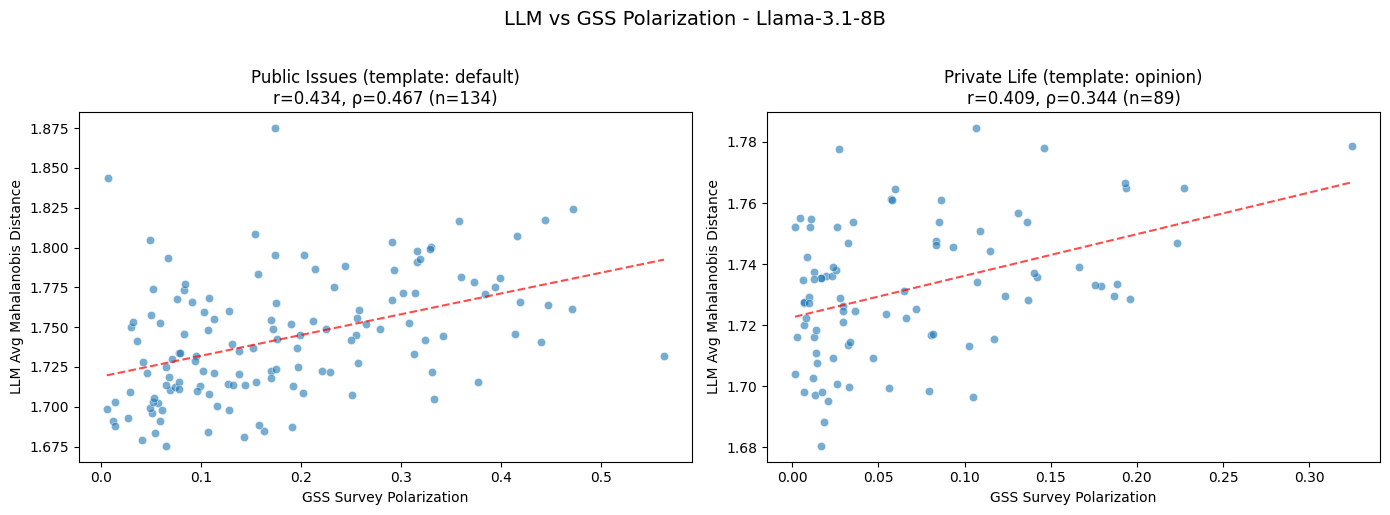

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for idx, corr in enumerate(correlation_results):
    ax = axes[idx]
    df_merged = corr['df_merged']
    
    sns.scatterplot(data=df_merged, x='GSS_Polarization', y='Avg_Mahalanobis', alpha=0.6, ax=ax)
    
    # Regression line
    z = np.polyfit(df_merged['GSS_Polarization'], df_merged['Avg_Mahalanobis'], 1)
    p = np.poly1d(z)
    x_line = np.linspace(df_merged['GSS_Polarization'].min(), df_merged['GSS_Polarization'].max(), 100)
    ax.plot(x_line, p(x_line), 'r--', alpha=0.7)
    
    cat_title = corr['category'].replace('_', ' ').title()
    template = CATEGORIES[corr['category']]['template_name']
    ax.set_title(f"{cat_title} (template: {template})\nr={corr['pearson']:.3f}, ρ={corr['spearman']:.3f} (n={corr['n_topics']})")
    ax.set_xlabel('GSS Survey Polarization')
    ax.set_ylabel('LLM Avg Mahalanobis Distance')

plt.suptitle(f'LLM vs GSS Polarization - {MODEL_NAME}', fontsize=14, y=1.02)
plt.tight_layout()

fig_path = OUTPUT_DIR / f"gss_correlation_{MODEL_NAME}_{timestamp}.png"
plt.savefig(fig_path, dpi=150, bbox_inches='tight')
print(f"Saved: {fig_path}")
plt.show()

## 8. Save Combined Results

In [ ]:
# Combine all results
df_combined = pd.concat([df for df in category_results.values()], ignore_index=True)
df_combined['model'] = MODEL_NAME

# Save combined results
combined_pkl = OUTPUT_DIR / f"df_gss_combined_{MODEL_NAME}_{timestamp}.pkl"
combined_csv = OUTPUT_DIR / f"df_gss_combined_{MODEL_NAME}_{timestamp}.csv"

df_combined.to_pickle(combined_pkl)
df_combined.to_csv(combined_csv, index=False)

# Save correlation summary
corr_csv = OUTPUT_DIR / f"gss_correlations_{MODEL_NAME}_{timestamp}.csv"
df_corr_summary.to_csv(corr_csv, index=False)

print("="*70)
print("FILES SAVED")
print("="*70)
print(f"\nResults directory: {OUTPUT_DIR.absolute()}")
print(f"\nFiles saved:")
for cat_name in CATEGORIES.keys():
    print(f"  - df_gss_{cat_name}_{MODEL_NAME}_{timestamp}.pkl")
print(f"  - {combined_pkl.name}")
print(f"  - {combined_csv.name}")
print(f"  - {corr_csv.name}")
print(f"  - gss_correlation_{MODEL_NAME}_{timestamp}.png")

FILES SAVED

Results directory: /project/jevans/maxzhuyt/../results

Files saved:
  - df_gss_public_issues_Llama-3.1-8B_20260128_210325.pkl
  - df_gss_private_life_Llama-3.1-8B_20260128_210325.pkl
  - df_gss_combined_Llama-3.1-8B_20260128_210325.pkl
  - df_gss_combined_Llama-3.1-8B_20260128_210325.csv
  - gss_correlations_Llama-3.1-8B_20260128_210325.csv
  - gss_correlation_Llama-3.1-8B_20260128_210325.png


## 9. Summary

In [ ]:
print("="*70)
print("ANALYSIS SUMMARY")
print("="*70)

print(f"\n[Run Info]")
print(f"  Model: {MODEL_NAME}")
print(f"  Timestamp: {timestamp}")
print(f"  Output directory: {OUTPUT_DIR.absolute()}")

print(f"\n[Topics Analyzed]")
for cat_name, df in category_results.items():
    template = CATEGORIES[cat_name]['template_name']
    print(f"  {cat_name}: {len(df)} topics (template: '{template}')")
print(f"  Total: {len(df_combined)} topics")

print(f"\n[Correlation with GSS Survey]")
for _, row in df_corr_summary.iterrows():
    print(f"  {row['Category']:15s}: r={row['Pearson_r']:.4f}, ρ={row['Spearman_rho']:.4f} (n={row['N_Topics']})")

print(f"\n[Configuration Used]")
print(f"  Batch size: {BATCH_SIZE}")
print(f"  Max length: {MAX_LENGTH}")
print(f"  Politicians: {len(load_politicians(NOMINATE_CSV))}")
print(f"  System message: \"{SYSTEM_MSG_POLITICIAN[:50]}...\"")
print(f"\n[Templates Used]")
for cat_name, cat_config in CATEGORIES.items():
    template = POLITICIAN_TEMPLATES[cat_config['template_name']]
    print(f"  {cat_name}: '{cat_config['template_name']}' → \"{template}\"")

ANALYSIS SUMMARY

[Run Info]
  Model: Llama-3.1-8B
  Timestamp: 20260128_210325
  Output directory: /project/jevans/maxzhuyt/../results

[Topics Analyzed]
  public_issues: 134 topics (template: 'default')
  private_life: 89 topics (template: 'opinion')
  Total: 223 topics

[Correlation with GSS Survey]
  public_issues  : r=0.4336, ρ=0.4674 (n=134)
  private_life   : r=0.4086, ρ=0.3442 (n=89)

[Configuration Used]
  Batch size: 80
  Max length: 128
  Politicians: 550
  System message: "You are simulating the public stance of U.S. polit..."

[Templates Used]
  public_issues: 'default' → "Generate a statement by {name} on {topic}."
  private_life: 'opinion' → "What would {name} say about {topic}?"


In [ ]:
# Optional: Unload model to free memory
# del model, tokenizer
# gc.collect()
# torch.cuda.empty_cache()
# print("Model unloaded.")